## Manuscript figures
### "How to make machine learning scoring functions competitive with FEP"


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys
from scipy.stats import pearsonr, kendalltau
from sklearn.metrics import mean_squared_error
import os

In [12]:
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['font.size'] = 10

In [13]:
data_path = "../data/"

### Main paper

#### Figure 1: AEV radial components

In [5]:
def cutoff_fn_ANI(x, Rc):
    return 0.5 * np.cos(np.pi * (x / Rc)) + 0.5

def radial_ANI(x, Rc, Eta, Rs):
    return np.exp(-Eta * (x - Rs)**2) * cutoff_fn_ANI(x, Rc)

RcR = 5.1  # Radial cutoff
EtaR = 19.7  # Radial decay
RsR_vec = [0.80, 1.34, 1.88, 2.41, 2.95, 3.49, 4.03, 4.56]  # Radial shift

def plot_radial_aevs(RcR, EtaR, RsR_vec, outpath=None):
    
    R = np.arange(0, RcR + 0.01, 0.01)
    data = {'R': R}

    for RsR in RsR_vec:
        col_name = f"{RsR:.2f}"
        data[col_name] = radial_ANI(R, RcR, EtaR, RsR)

    data_long = pd.melt(pd.DataFrame(data), id_vars='R', var_name='Center', value_name='value')

    plt.figure(figsize=(6, 3))

    sns.lineplot(data=data_long, x='R', y='value', hue='Center', linewidth=1.5)

    plt.ylabel(r'$C(R_{ij})$')
    plt.xlabel(r'$R_{ij}\ (\AA)$')
    plt.legend(title=r"R$_s$ ($\AA$)", title_fontsize='10', fontsize='9', frameon=False)

    if outpath:
        plt.savefig(outpath, bbox_inches='tight')

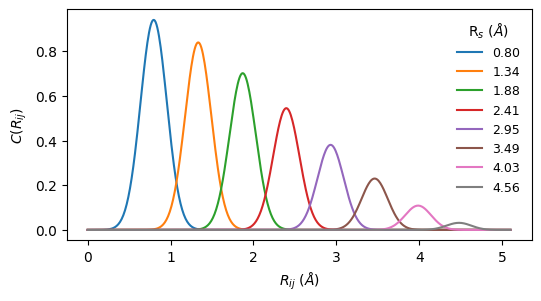

In [14]:
#plot_radial_aevs(RcR, EtaR, RsR_vec, outpath='figure1.pdf')
plot_radial_aevs(RcR, EtaR, RsR_vec, outpath='figure1.png')

#### Figure 2: AEV-PLIG model schematic

Created separately.

#### Figure 3: AEV-PLIG baseline performance

In [15]:
def rmse(true, pred):
    return np.sqrt(mean_squared_error(true, pred))

def pk_to_dg(pk):
    """ Convert pK to free energy in kcal/mol."""
    r = 8.3145  # J/mol/K
    t = 297  # K
    k = 10**-pk
    dg_j = r * t * np.log(k)  # Natural log
    dg_kcal = dg_j / 4184

    return dg_kcal

def format_marginal(ax, horizontal=True):

        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if horizontal:
            ax.spines['left'].set_visible(False)
            ax.invert_xaxis()
            
        else:
            ax.spines['bottom'].set_visible(False)
            ax.invert_yaxis()

        ax.set_ylabel('')
        ax.set_xlabel('')

def plot_scatter_with_marginals(df1, df2, x_col, y_col, group_col, outpath=None):

    fig = plt.figure(figsize=(4, 7), constrained_layout=True)

    widths = [4, 0.6]
    heights = [0.6, 4, 0.6, 4]
    lims = [-16, -2]

    spec = fig.add_gridspec(ncols=2, nrows=4, width_ratios=widths,
                        height_ratios=heights)
    
    # Dotted x=y line
    ax1 = fig.add_subplot(spec[1, 0])
    ax1.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    ax2 = fig.add_subplot(spec[3, 0])
    ax2.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    # Scatter plots
    sns.scatterplot(data=df1, x=x_col, y=y_col, color='darkorange', ax=ax1, legend=False, edgecolor='black', alpha=0.6, zorder=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlabel('')
    ax1.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax1.set_xticks([-16,-12,-8,-4])

    sns.scatterplot(data=df2, x=x_col, y=y_col, color='forestgreen', ax=ax2, legend=False,  edgecolor='black', alpha=0.6, zorder=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlabel(r'Exp. $\Delta$G (kcal/mol)')
    ax2.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax2.set_xticks(np.arange(lims[0],lims[1],-2))
    ax2.set_xticks([-16,-12,-8,-4])

    # Marginal histograms (remove labels, ticks and boxes)
    ax1_marg_x = fig.add_subplot(spec[0, 0])
    sns.kdeplot(data=df1, x=x_col, color='darkorange', ax=ax1_marg_x, legend=False)
    format_marginal(ax1_marg_x)
    ax1_marg_x.set_xlim(lims)
    
    ax1_marg_y = fig.add_subplot(spec[1, 1])
    sns.kdeplot(data=df1, y=y_col, color='darkorange', ax=ax1_marg_y, legend=False)
    format_marginal(ax1_marg_y, horizontal=False)
    ax1_marg_y.set_ylim(lims)

    ax2_marg_x = fig.add_subplot(spec[2, 0])
    sns.kdeplot(data=df2, x=x_col, color='forestgreen', ax=ax2_marg_x, legend=False)
    format_marginal(ax2_marg_x)
    ax2_marg_x.set_xlim(lims)

    ax2_marg_y = fig.add_subplot(spec[3, 1])
    sns.kdeplot(data=df2, y=y_col, color='forestgreen', ax=ax2_marg_y, legend=False)
    format_marginal(ax2_marg_y, horizontal=False)
    ax2_marg_y.set_ylim(lims)

    # Annotations
    ax1.set_title('a)', loc='left', position=(-0.2, 1.0), fontsize=12)
    ax2.set_title('b)', loc='left', position=(-0.2, 1.0), fontsize=12)

    ax1_pcc, ax1_kt, ax1_rmse = pearsonr(df1[x_col], df1[y_col])[0], kendalltau(df1[x_col], df1[y_col])[0], rmse(df1[x_col], df1[y_col])
    ax2_pcc, ax2_kt, ax2_rmse = pearsonr(df2[x_col], df2[y_col])[0], kendalltau(df2[x_col], df2[y_col])[0], rmse(df2[x_col], df2[y_col])
    ax1.text(-16, -4, f'PCC = {ax1_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax1_kt:.2f}\nRMSE = {ax1_rmse:.2f}', fontsize=9)
    ax2.text(-16, -4, f'PCC = {ax2_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax2_kt:.2f}\nRMSE = {ax2_rmse:.2f}', fontsize=9)

    if outpath:
        plt.tight_layout(w_pad=1, h_pad=0)
        plt.savefig(outpath, bbox_inches='tight')

In [16]:
ood_baseline_predictions = pd.read_csv(os.path.join(data_path, "baseline/AEV-PLIG_oodtest_predictions.csv"))
ood_baseline_predictions.rename(columns={'preds': 'preds_pk'}, inplace=True)
ood_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['pK']]
ood_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['preds_pk']]
ood_baseline_predictions['Target'] = 'OOD'

casf16_baseline_predictions = pd.read_csv(os.path.join(data_path, "baseline/AEV-PLIG_casf2016_pdbbind_predictions.csv"))
casf16_baseline_predictions.rename(columns={'preds': 'preds_pk'}, inplace=True)
casf16_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['truth']]
casf16_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['preds_pk']]
casf16_baseline_predictions['Target'] = 'CASF2016'

/var/folders/by/3h2zsn3x1ns_mm2kkjxywzj40000gn/T/ipykernel_22370/3378563848.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=1, h_pad=0)


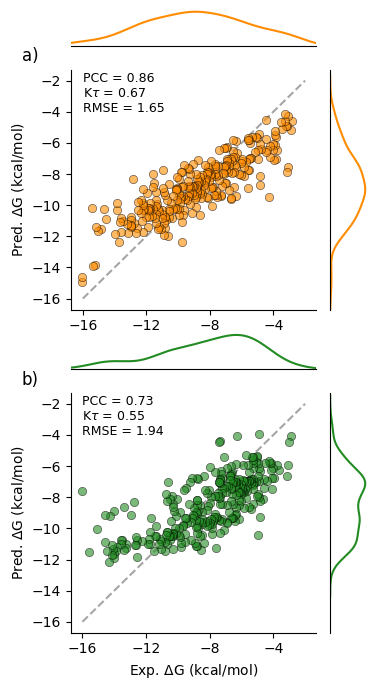

In [17]:
#plot_scatter_with_marginals(casf16_baseline_predictions,ood_baseline_predictions, 'Exp. ΔG', 'preds', 'Target', './figure3.pdf')
plot_scatter_with_marginals(casf16_baseline_predictions,ood_baseline_predictions, 'Exp. ΔG', 'preds', 'Target', './figure3.png')

#### Figure 4: AEV-PLIG performance and training set similarity

In [18]:
def weighted_mean(num_per_set, value_per_set):
    return np.sum(num_per_set*value_per_set) / np.sum(num_per_set)

def get_bootstrap_weighted_value(num_set, value_set, nboots=10000):
    value_samples = np.zeros(nboots)
    for b in range(nboots):
        inds = np.random.choice(len(value_set), len(value_set))
        value_samples[b] = weighted_mean(num_set[inds], value_set[inds])

    return np.percentile(value_samples, 2.5), np.percentile(value_samples, 97.5)


def get_weighted_stats(results, preds_col, truth_col, groups):
    results["pred"] = results[preds_col]
    results["truth"] = results[truth_col]

    logs = []
    for target in groups:
        subset = results[results["group_id"] == target]
        logs.append(
            [
                target,
                pearsonr(subset["pred"], subset["truth"])[0],
                kendalltau(subset["pred"], subset["truth"])[0],
                rmse(subset["pred"], subset["truth"]),
                len(subset),
            ]
        )

    performance = pd.DataFrame(
        logs, columns=["Target", "Pearson's R", "Kendall's Tau", "RMSE", "Sample size"]
    )

    wpcc = weighted_mean(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
    wpcc_low, wpcc_high = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Pearson's R"]))
    wktau = weighted_mean(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))
    wktau_low, wktau_high = get_bootstrap_weighted_value(np.array(performance["Sample size"]), np.array(performance["Kendall's Tau"]))

    return wpcc, wpcc_low, wpcc_high, wktau, wktau_low, wktau_high


def get_performance_df(results, preds_col, truth_col, groups):
    results["pred"] = results[preds_col]
    results["truth"] = results[truth_col]

    logs = []
    for target in groups:
        subset = results[results["group_id"] == target]
        logs.append(
            [
                target,
                pearsonr(subset["pred"], subset["truth"])[0],
                kendalltau(subset["pred"], subset["truth"])[0],
                rmse(subset["pred"], subset["truth"]),
                len(subset),
            ]
        )

    performance = pd.DataFrame(
        logs, columns=["Target", "Pearson's R", "Kendall's Tau", "RMSE", "Sample size"]
    )
    return performance


def plot_lineplot_with_error_bars(
    fep_pcc_data,
    fep_ktau_data,
    df,
    df_baseline,
    label_fep,
    label,
    label_baseline,
    pcc_lims,
    ktau_lims,
    pcc_ticks,
    ktau_ticks,
    xlabel,
    invert_xaxis=False,
    outpath=None,
):
    color = "steelblue"
    color_baseline = "green"
    color_fep = "firebrick"

    fig = plt.figure(figsize=(4, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)

    # plot PCC data
    ax1.axhline(y=fep_pcc_data[0], color=color_fep, linestyle="--", label=label_fep, lw=2)
    ax1.axhspan(ymin=fep_pcc_data[1], ymax=fep_pcc_data[2], facecolor=color_fep, edgecolor=None, alpha=0.3)

    sns.lineplot(
        data = df,
        x="Tanimoto",
        y="WPCC",
        label=label,
        color=color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1
    )
    errors = np.array([df["WPCC"] - df["WPCC_low"], df["WPCC_high"] - df["WPCC"]])
    ax1.errorbar(df["Tanimoto"], df["WPCC"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color, capthick=1.5, zorder=0)

    sns.lineplot(
        data = df_baseline,
        x="Tanimoto",
        y="WPCC",
        label=label_baseline,
        color=color_baseline,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax1
    )
    errors = np.array([df_baseline["WPCC"] - df_baseline["WPCC_low"], df_baseline["WPCC_high"] - df_baseline["WPCC"]])
    ax1.errorbar(df_baseline["Tanimoto"], df_baseline["WPCC"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color_baseline, capthick=1.5, zorder=0)

    # plot Ktau data
    ax2.axhline(y=fep_ktau_data[0], color=color_fep, linestyle="--", lw=2)
    ax2.axhspan(ymin=fep_ktau_data[1], ymax=fep_ktau_data[2], facecolor=color_fep, edgecolor=None, alpha=0.3)

    sns.lineplot(
        data = df,
        x="Tanimoto",
        y="WKtau",
        color=color,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False
    )
    errors = np.array([df["WKtau"] - df["WKtau_low"], df["WKtau_high"] - df["WKtau"]])
    ax2.errorbar(df["Tanimoto"], df["WKtau"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color, capthick=1.5, zorder=0)

    sns.lineplot(
        data = df_baseline,
        x="Tanimoto",
        y="WKtau",
        color=color_baseline,
        marker="o",
        ms=10,
        lw=2,
        markeredgecolor="black",
        markeredgewidth=1.1,
        ax=ax2,
        legend=False
    )

    errors = np.array([df_baseline["WKtau"] - df_baseline["WKtau_low"], df_baseline["WKtau_high"] - df_baseline["WKtau"]])
    ax2.errorbar(df_baseline["Tanimoto"], df_baseline["WKtau"], yerr=errors, fmt='o', capsize=4, elinewidth=1.5, ecolor=color_baseline, capthick=1.5, zorder=0)

    ax1.set_ylabel("Weighted mean PCC")
    ax1.set_xlabel("")
    ax1.set_ylim(pcc_lims)
    if invert_xaxis:
        ax1.invert_xaxis()
    ax1.set_yticks(pcc_ticks)
    ax1.set_xticks([0.9, 0.8, 0.7, 0.6])
    ax1.set_title("a)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"Weighted mean K$\tau$")
    ax2.set_ylim(ktau_lims)
    ax2.set_yticks(ktau_ticks)
    ax2.set_xticks([0.9, 0.8, 0.7, 0.6])
    ax2.set_title("b)", loc="left", fontsize=14, position=(-0.25, 1.0))

    ax1.legend(bbox_to_anchor=(0.5, 1.25), loc="center", frameon=False)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath)

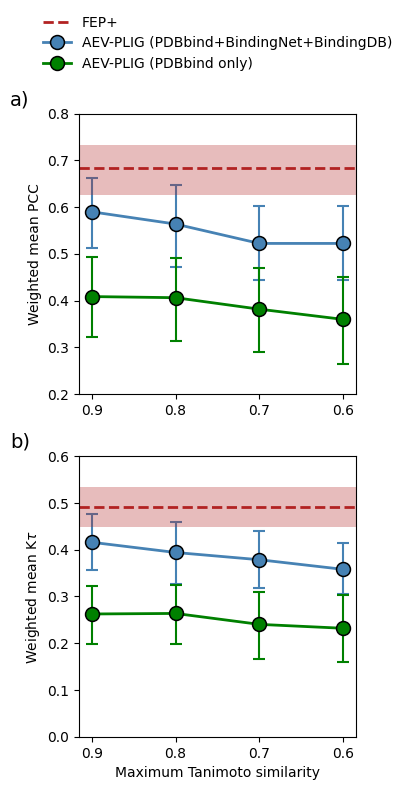

In [19]:
fep_index = pd.read_csv(os.path.join(data_path, "fep/fep_benchmark_fep+_predictions.csv"), index_col=0)
counts = pd.DataFrame(fep_index["group_id"].value_counts())
groups = list(counts[counts["count"] >= 10].index)

fep_wpcc, fep_wpcc_low, fep_wpcc_high, fep_wktau, fep_wktau_low, fep_wktau_high = get_weighted_stats(fep_index, 'Pred. dG (kcal/mol)', 'Exp. dG (kcal/mol)', groups)
fep_index = fep_index[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id":"unique_id"})

# baseline
results = pd.read_csv(os.path.join(data_path, "baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls90_wpcc, baseline_ls90_wpcc_low, baseline_ls90_wpcc_high, baseline_ls90_wktau, baseline_ls90_wktau_low, baseline_ls90_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv(os.path.join(data_path, "baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim80_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls80_wpcc, baseline_ls80_wpcc_low, baseline_ls80_wpcc_high, baseline_ls80_wktau, baseline_ls80_wktau_low, baseline_ls80_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv(os.path.join(data_path, "baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim70_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls70_wpcc, baseline_ls70_wpcc_low, baseline_ls70_wpcc_high, baseline_ls70_wktau, baseline_ls70_wktau_low, baseline_ls70_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv(os.path.join(data_path, "baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim60_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
baseline_ls60_wpcc, baseline_ls60_wpcc_low, baseline_ls60_wpcc_high, baseline_ls60_wktau, baseline_ls60_wktau_low, baseline_ls60_wktau_high = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

# bindingnet_bindingdb
results = pd.read_csv(os.path.join(data_path, "bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls90_wpcc, bindingnet_bindingdb_ls90_wpcc_low, bindingnet_bindingdb_ls90_wpcc_high, bindingnet_bindingdb_ls90_wktau, bindingnet_bindingdb_ls90_wktau_low, bindingnet_bindingdb_ls90_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv(os.path.join(data_path, "bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim80_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls80_wpcc, bindingnet_bindingdb_ls80_wpcc_low, bindingnet_bindingdb_ls80_wpcc_high, bindingnet_bindingdb_ls80_wktau, bindingnet_bindingdb_ls80_wktau_low, bindingnet_bindingdb_ls80_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv(os.path.join(data_path, "bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim70_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls70_wpcc, bindingnet_bindingdb_ls70_wpcc_low, bindingnet_bindingdb_ls70_wpcc_high, bindingnet_bindingdb_ls70_wktau, bindingnet_bindingdb_ls70_wktau_low, bindingnet_bindingdb_ls70_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

results = pd.read_csv(os.path.join(data_path, "bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim60_predictions.csv"))
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
bindingnet_bindingdb_ls60_wpcc, bindingnet_bindingdb_ls60_wpcc_low, bindingnet_bindingdb_ls60_wpcc_high, bindingnet_bindingdb_ls60_wktau, bindingnet_bindingdb_ls60_wktau_low, bindingnet_bindingdb_ls60_wktau_high  = get_weighted_stats(results, 'preds', 'Exp. dG (kcal/mol)', groups)

df = pd.DataFrame(
    {
        "Tanimoto": [0.9, 0.8, 0.7, 0.6],
        "WPCC": [bindingnet_bindingdb_ls90_wpcc, bindingnet_bindingdb_ls80_wpcc, bindingnet_bindingdb_ls70_wpcc, bindingnet_bindingdb_ls70_wpcc],
        "WPCC_low": [bindingnet_bindingdb_ls90_wpcc_low, bindingnet_bindingdb_ls80_wpcc_low, bindingnet_bindingdb_ls70_wpcc_low, bindingnet_bindingdb_ls70_wpcc_low],
        "WPCC_high": [bindingnet_bindingdb_ls90_wpcc_high, bindingnet_bindingdb_ls80_wpcc_high, bindingnet_bindingdb_ls70_wpcc_high, bindingnet_bindingdb_ls70_wpcc_high],
        "WKtau": [bindingnet_bindingdb_ls90_wktau, bindingnet_bindingdb_ls80_wktau, bindingnet_bindingdb_ls70_wktau, bindingnet_bindingdb_ls60_wktau],
        "WKtau_low": [bindingnet_bindingdb_ls90_wktau_low, bindingnet_bindingdb_ls80_wktau_low, bindingnet_bindingdb_ls70_wktau_low, bindingnet_bindingdb_ls60_wktau_low],
        "WKtau_high": [bindingnet_bindingdb_ls90_wktau_high, bindingnet_bindingdb_ls80_wktau_high, bindingnet_bindingdb_ls70_wktau_high, bindingnet_bindingdb_ls60_wktau_high],
    }
)

df_baseline = pd.DataFrame(
    {
        "Tanimoto": [0.9, 0.8, 0.7, 0.6],
        "WPCC": [baseline_ls90_wpcc, baseline_ls80_wpcc, baseline_ls70_wpcc, baseline_ls60_wpcc],
        "WPCC_low": [baseline_ls90_wpcc_low, baseline_ls80_wpcc_low, baseline_ls70_wpcc_low, baseline_ls60_wpcc_low],
        "WPCC_high": [baseline_ls90_wpcc_high, baseline_ls80_wpcc_high, baseline_ls70_wpcc_high, baseline_ls60_wpcc_high],
        "WKtau": [baseline_ls90_wktau, baseline_ls80_wktau, baseline_ls70_wktau, baseline_ls60_wktau],
        "WKtau_low": [baseline_ls90_wktau_low, baseline_ls80_wktau_low, baseline_ls70_wktau_low, baseline_ls60_wktau_low],
        "WKtau_high": [baseline_ls90_wktau_high, baseline_ls80_wktau_high, baseline_ls70_wktau_high, baseline_ls60_wktau_high],
    }
)

# plot_lineplot_with_error_bars(
#     [fep_wpcc, fep_wpcc_low, fep_wpcc_high],
#     [fep_wktau, fep_wktau_low, fep_wktau_high],
#     df,
#     df_baseline,
#     "FEP+",
#     "AEV-PLIG (PDBbind+BindingNet+BindingDB)",
#     "AEV-PLIG (PDBbind only)",
#     [0.2, 0.8],
#     [0.0, 0.6],
#     [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
#     [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
#     xlabel="Maximum Tanimoto similarity",
#     invert_xaxis=True,
#     outpath="./figure4.pdf",
# )

plot_lineplot_with_error_bars(
    [fep_wpcc, fep_wpcc_low, fep_wpcc_high],
    [fep_wktau, fep_wktau_low, fep_wktau_high],
    df,
    df_baseline,
    "FEP+",
    "AEV-PLIG (PDBbind+BindingNet+BindingDB)",
    "AEV-PLIG (PDBbind only)",
    [0.2, 0.8],
    [0.0, 0.6],
    [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    xlabel="Maximum Tanimoto similarity",
    invert_xaxis=True,
    outpath="./figure4.png",
)

In [20]:
bindingnet_bindingdb_ls90_wpcc, bindingnet_bindingdb_ls90_wktau

(0.5897892830212949, 0.41581535829748073)

#### Figure 5: AEV-PLIG performance vs FEP barplot

In [15]:
def plot_bars_comparison(df1, df2, df3, column1, column2, xlabel='', y1_label='', y2_label='', y1_lim=(0,1), y2_lim=(0,2), outpath=None):
    
    color = "steelblue"
    color_baseline = "green"
    color_fep = "indianred"

    labels = df1.Target
    x = [x for x in range(14)]
    
    bar_width = 0.23

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, constrained_layout=True)
    
    bars1_1 = ax1.bar(x, df1[column1], bar_width, label='AEV-PLIG (PDBbind only)', facecolor=color_baseline, edgecolor='black')
    bars1_2 = ax1.bar([i + bar_width for i in x], df2[column1], bar_width, label='AEV-PLIG (PDBbind+BindingNet+BindingDB)', facecolor=color, edgecolor='black')
    bars1_3 = ax1.bar([i + 2*bar_width for i in x], df3[column1], bar_width, label='FEP+', facecolor=color_fep, edgecolor='black')

    bars2_1 = ax2.bar(x, df1[column2], bar_width, label='AEV-PLIG (PDBbind only)', facecolor=color_baseline, edgecolor='black')
    bars2_2 = ax2.bar([i + bar_width for i in x], df2[column2], bar_width, label='AEV-PLIG (PDBbind+BindingNet+BindingDB)', facecolor=color, edgecolor='black')
    bars2_3 = ax2.bar([i + 2*bar_width for i in x], df3[column2], bar_width, label='FEP', facecolor=color_fep, edgecolor='black')

    ax1.set_ylim(y1_lim)
    ax2.set_ylim(y2_lim)

    ax2.set_xlabel(xlabel, labelpad=1)
    ax1.set_ylabel(y1_label)
    ax2.set_ylabel(y2_label)

    ax1.set_xticks([i + bar_width for i in x])
    ax2.set_xticks([i + bar_width for i in x])
    ax2.set_xticklabels(labels)
    ax1.legend(ncol=3, frameon=False, loc='upper left', bbox_to_anchor=(0.025, 1.25))
    
    plt.xticks(rotation=90)

    if outpath:
        plt.tight_layout(pad=1)
        plt.savefig(outpath, dpi=500)

In [21]:
# load FEP+ results
results = pd.read_csv(
    os.path.join(data_path, "fep/fep_benchmark_fep+_predictions.csv"), index_col=0
)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 25].index)
groups.remove("jacs_set/bace")
performance_fep = get_performance_df(
    results, "Pred. dG (kcal/mol)", "Exp. dG (kcal/mol)", groups
)
print("FEP+")
print("WPCC:", weighted_mean(np.array(performance_fep["Sample size"]), np.array(performance_fep["Pearson's R"])))
print("WKtau:", weighted_mean(np.array(performance_fep["Sample size"]), np.array(performance_fep["Kendall's Tau"])))

# load AEV-PLIG results
fep_index = pd.read_csv(
    os.path.join(data_path, "fep/fep_benchmark_fep+_predictions.csv"), index_col=0
)
fep_index = fep_index[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id": "unique_id"})
results = pd.read_csv(
    os.path.join(
        data_path,
        "bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv",
    )
)
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_aevplig = get_performance_df(results, "preds", "Exp. dG (kcal/mol)", groups)
print("AEV-PLIG")
print("WPCC:", weighted_mean(np.array(performance_aevplig["Sample size"]), np.array(performance_aevplig["Pearson's R"])))
print("WKtau:", weighted_mean(np.array(performance_aevplig["Sample size"]), np.array(performance_aevplig["Kendall's Tau"])))

# baseline AEV-PLIG
results = pd.read_csv(
    os.path.join(
        data_path, "baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv"
    )
)
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_baseline = get_performance_df(
    results, "preds", "Exp. dG (kcal/mol)", groups
)
print("AEV-PLIG baseline")
print("WPCC:", weighted_mean(np.array(performance_baseline["Sample size"]), np.array(performance_baseline["Pearson's R"])))
print("WKtau:", weighted_mean(np.array(performance_baseline["Sample size"]), np.array(performance_baseline["Kendall's Tau"])))

# Change Target names
target_dict = {
    "gpcrs/ox2_hip_custcore": "OX2",
    "merck/syk_4puz_fullmap": "SYK",
    "jacs_set/mcl1_extra_flips": "Mcl1",
    "merck/hif2a_automap": "HIF2α",
    "merck/pfkfb3_automap": "PFKFB3",
    "jacs_set/p38": "p38",
    "merck/eg5_extraprotomers": "Eg5",
    "janssen_bace/bace_ciordia_retro": "BACE1",
    "merck/tnks2_fullmap": "TNKS2",
    "merck/cdk8_5cei_new_helix_loop_extra": "CDK8",
    "mcs_docking/renin_customcore": "Renin",
    "opls_stress/fxa_yoshikawa_set": "Factor Xa",
    "misc/galectin3_extra": "Galectin",
    "merck/shp2": "SHP-2",
}

performance_fep["Target"] = performance_fep["Target"].map(target_dict)
performance_aevplig["Target"] = performance_aevplig["Target"].map(target_dict)
performance_baseline["Target"] = performance_baseline["Target"].map(target_dict)

# print table of performance
performance = performance_fep.merge(
    performance_aevplig, on="Target", suffixes=("_fep", "_aevplig")
)
performance = performance[
    [
        "Target",
        "Pearson's R_fep",
        "Pearson's R_aevplig",
        "Kendall's Tau_fep",
        "Kendall's Tau_aevplig",
        "RMSE_fep",
        "RMSE_aevplig",
    ]
]

# plot_bars_comparison(
#     performance_baseline,
#     performance_aevplig,
#     performance_fep,
#     "Pearson's R",
#     "Kendall's Tau",
#     xlabel="Target",
#     y1_label="PCC",
#     y2_label=r"K$\tau$",
#     y1_lim=(-0.2, 1),
#     y2_lim=(-0.2, 1),
#     outpath="figure5.pdf",
# )

# plot_bars_comparison(
#     performance_baseline,
#     performance_aevplig,
#     performance_fep,
#     "Pearson's R",
#     "Kendall's Tau",
#     xlabel="Target",
#     y1_label="PCC",
#     y2_label=r"K$\tau$",
#     y1_lim=(-0.2, 1),
#     y2_lim=(-0.2, 1),
#     outpath="figure5.png",
# )

FEP+
WPCC: 0.6946584747034932
WKtau: 0.4931852242929745
AEV-PLIG
WPCC: 0.5828799351363071
WKtau: 0.4258298492265272
AEV-PLIG baseline
WPCC: 0.36093940799996077
WKtau: 0.24848635439798303


In [22]:
threshold = 0.2
aev_better, fep_better, no_diff = [], [], []

for fp, ap in zip(performance_fep["Pearson's R"], performance_aevplig["Pearson's R"]):
    if abs(fp - ap) > threshold:
        if fp > ap:
            fep_better.append((fp, ap))
        else:
            aev_better.append((fp, ap))
    else:
        no_diff.append((fp, ap))

print("FEP+ better:", len(fep_better))
print("AEV-PLIG better:", len(aev_better))
print("No difference:", len(no_diff))

FEP+ better: 5
AEV-PLIG better: 0
No difference: 9


In [23]:
threshold = 0.2
aev_better, fep_better, no_diff = [], [], []

for fp, ap in zip(performance_fep["Kendall's Tau"], performance_aevplig["Kendall's Tau"]):
    if abs(fp - ap) > threshold:
        if fp > ap:
            fep_better.append((fp, ap))
        else:
            aev_better.append((fp, ap))
    else:
        no_diff.append((fp, ap))

print("FEP+ better:", len(fep_better))
print("AEV-PLIG better:", len(aev_better))
print("No difference:", len(no_diff))

FEP+ better: 3
AEV-PLIG better: 1
No difference: 10


## Supplementary Figures

In [25]:
def plot_dot_plot(systems, fep_data, aevplig_data, baseline_data, outpath=None):
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 14), sharey=True, constrained_layout=True)
    y = np.arange(0, len(systems), 1)

    # Sort each dataset by system alphabetically
    fep_data = fep_data.sort_values("Target")
    aevplig_data = aevplig_data.sort_values("Target")
    baseline_data = baseline_data.sort_values("Target")

    # plot FEP+ data on the left axis
    ax1.scatter(
        fep_data["Pearson's R"],
        y,
        color="indianred",
        label="FEP+",
        alpha=1,
        marker='^',
        s=50,
    )

    ax2.scatter(
        fep_data["Kendall's Tau"],
        y,
        color="indianred",
        label="FEP+",
        alpha=1,
        marker='^',
        s=50,
    )

    # plot AEV-PLIG data
    ax1.scatter(
        aevplig_data["Pearson's R"],
        y,
        color="steelblue",
        label="AEV-PLIG (PDBbind+BindingNet+BindingDB)",
        alpha=0.8,
        marker='o',
        s=30
    )

    ax2.scatter(
        aevplig_data["Kendall's Tau"],
        y,
        color="steelblue",
        label="AEV-PLIG (PDBbind+BindingNet+BindingDB)",
        alpha=0.8,
        marker='o',
        s=30
    )

    ax1.scatter(
        baseline_data["Pearson's R"],
        y,
        color="green",
        label="AEV-PLIG (PDBbind only)",
        alpha=0.8,
        marker='o',
        s=30,
    )

    ax2.scatter(
        baseline_data["Kendall's Tau"],
        y,
        color="green",
        label="AEV-PLIG (PDBbind only)",
        alpha=0.8,
        marker='o',
        s=30
    )

    # Draw a grey line between the baseline and AEV-PLIG data
    for i in range(len(systems)):
        ax1.plot(
            [baseline_data["Pearson's R"].iloc[i], aevplig_data["Pearson's R"].iloc[i]],
            [y[i], y[i]],
            color="black",
            linestyle=":",
            alpha=0.9,
            zorder=0,
        )
        ax2.plot(
            [baseline_data["Kendall's Tau"].iloc[i], aevplig_data["Kendall's Tau"].iloc[i]],
            [y[i], y[i]],
            color="black",
            linestyle=":",
            alpha=0.9,
            zorder=1,
        )

    # Calculate weighed averages for each model using the number of samples per system
    fep_wpcc = weighted_mean(np.array(fep_data["Sample size"]), np.array(fep_data["Pearson's R"]))
    fep_wktau = weighted_mean(np.array(fep_data["Sample size"]), np.array(fep_data["Kendall's Tau"]))
    bl_wpcc = weighted_mean(np.array(baseline_data["Sample size"]), np.array(baseline_data["Pearson's R"]))
    bl_wktau = weighted_mean(np.array(baseline_data["Sample size"]), np.array(baseline_data["Kendall's Tau"]))
    aev_wpcc = weighted_mean(np.array(aevplig_data["Sample size"]), np.array(aevplig_data["Pearson's R"]))
    aev_wktau = weighted_mean(np.array(aevplit_data["Sample size"]), np.array(aevplig_data["Kendall's Tau"]))

    # Plot weighted averages at vetical lines
    

    # Add gridlines
    grid_x = np.arange(-0.2,1.0,0.2)
    ax1.grid(axis='x', linestyle='-', alpha=0.5, zorder=0)
    ax2.grid(axis='x', linestyle='-', alpha=0.5, zorder=0)

    ax1.set_xlabel("Pearson's R")
    ax2.set_xlabel("Kendall's Tau")
    ax1.set_yticks(y)
    ax1.set_yticklabels(fep_data["Target"])
    ax1.set_xlim(-0.4, 1)
    ax2.set_xlim(-0.4, 1)
    ax1.set_ylim(-1, len(systems))
    plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.07))

    if outpath:
        plt.tight_layout()
        plt.savefig(outpath, bbox_inches='tight')

NameError: name 'aevplit_data' is not defined

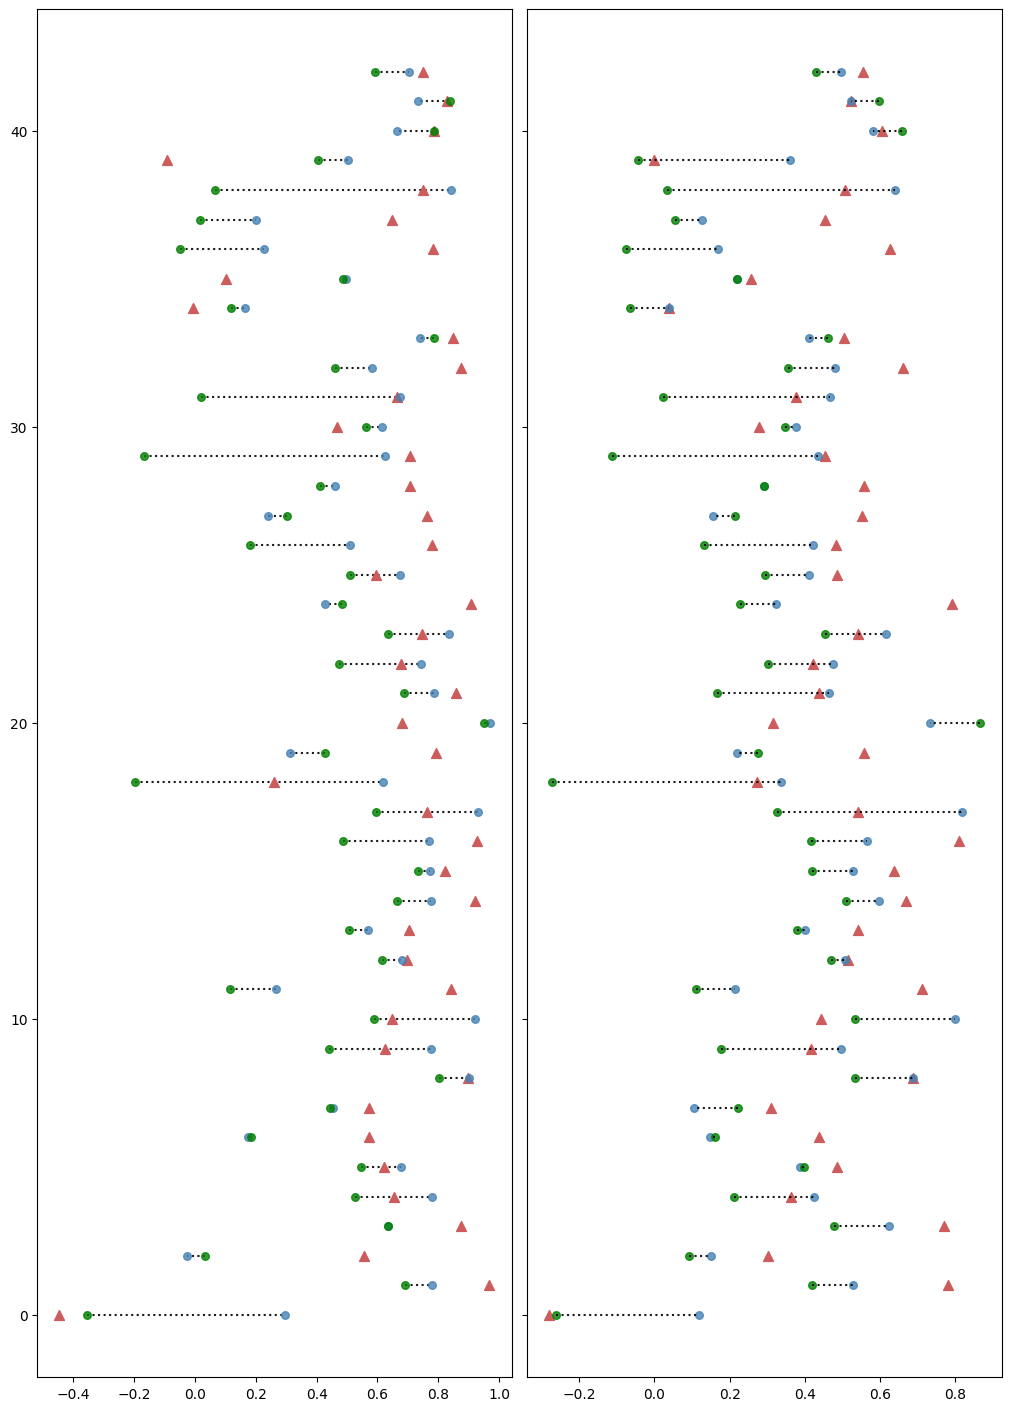

In [26]:
# load FEP+ results
results = pd.read_csv(
    os.path.join(data_path, "fep/fep_benchmark_fep+_predictions.csv"), index_col=0
)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 10].index)
performance_fep = get_performance_df(
    results, "Pred. dG (kcal/mol)", "Exp. dG (kcal/mol)", groups
)

# load AEV-PLIG results
fep_index = pd.read_csv(
    os.path.join(data_path, "fep/fep_benchmark_fep+_predictions.csv"), index_col=0
)
fep_index = fep_index[["graph_id", "Exp. dG (kcal/mol)"]]
fep_index = fep_index.rename(columns={"graph_id": "unique_id"})
results = pd.read_csv(
    os.path.join(
        data_path,
        "bindingnet_bindingdb/AEV-PLIG_fep_benchmark_pdbbind_U_bindingnet_U_bindingdb_ligsim90_predictions.csv",
    )
)
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_aevplig = get_performance_df(results, "preds", "Exp. dG (kcal/mol)", groups)

# baseline AEV-PLIG
results = pd.read_csv(
    os.path.join(
        data_path, "baseline/AEV-PLIG_fep_benchmark_pdbbind_ligsim90_predictions.csv"
    )
)
results["preds"] = [pk_to_dg(pk) for pk in results["preds"]]
results = results.merge(fep_index, how="left", on="unique_id")
performance_baseline = get_performance_df(
    results, "preds", "Exp. dG (kcal/mol)", groups
)

plot_dot_plot(
    groups,
    performance_fep,
    performance_aevplig,
    performance_baseline,
    outpath="fep-benchmarks-all.png",
)

In [27]:
performance_fep

,Target,Pearson's R,Kendall's Tau,RMSE,Sample size
0,gpcrs/ox2_hip_custcore,0.573577,0.436592,1.132199,51
1,merck/syk_4puz_fullmap,0.707899,0.453488,0.745969,46
2,jacs_set/mcl1_extra_flips,0.697509,0.515716,0.863465,42
3,merck/hif2a_automap,0.778429,0.482509,0.768081,41
4,merck/pfkfb3_automap,0.763210,0.552919,0.990554,40
5,jacs_set/bace,0.624343,0.417605,0.751584,36
6,jacs_set/p38,0.702335,0.542688,0.805331,34
7,merck/eg5_extraprotomers,0.596017,0.484963,0.880046,34
8,janssen_bace/bace_ciordia_retro,0.763888,0.540438,0.811740,33
9,merck/tnks2_fullmap,0.465720,0.279429,1.232121,33


In [59]:
def plot_dg_dist(dg_data, outpath=None):

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    for group in dg_data['group_id']:
        sns.kdeplot(dg_data[dg_data["group_id"] == group]["Exp. dG (kcal/mol)"], ax=ax, label=group)
    
    if outpath:
        plt.savefig(outpath)

def plot_dg_violin(dg_data, outpath=None):
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='group_id', y='Exp. dG (kcal/mol)', data=dg_data, cut=0)
    plt.xlabel('Group ID')
    plt.ylabel('Experimental ΔG (kcal/mol)')
    plt.title('Distribution of Experimental ΔG by Group')
    plt.xticks(rotation=45)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath)
    else:
        plt.show()

import math

def plot_dg_hist_grid(dg_data, outpath=None):
    groups = dg_data['group_id'].unique()
    num_groups = len(groups)
    
    # Determine grid size (3 columns)
    cols = 4
    rows = math.ceil(num_groups / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    bins=np.arange(min(dg_data['Exp. dG (kcal/mol)']), max(dg_data['Exp. dG (kcal/mol)']), 1)
    
    for i, group in enumerate(groups):
        sns.histplot(
            data=dg_data[dg_data['group_id'] == group],
            bins=bins,
            x='Exp. dG (kcal/mol)',
            ax=axes[i]
        )
        axes[i].set_title(f'Group {group}')
        axes[i].set_xlabel('Experimental ΔG (kcal/mol)')
        axes[i].set_ylabel('Density')
    
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath)
    else:
        plt.show()

In [60]:
# load FEP+ results
results = pd.read_csv(
    os.path.join(data_path, "fep/fep_benchmark_fep+_predictions.csv"), index_col=0
)
counts = pd.DataFrame(results["group_id"].value_counts())
groups = list(counts[counts["count"] >= 10].index)
performance_fep = get_performance_df(
    results, "Pred. dG (kcal/mol)", "Exp. dG (kcal/mol)", groups
)

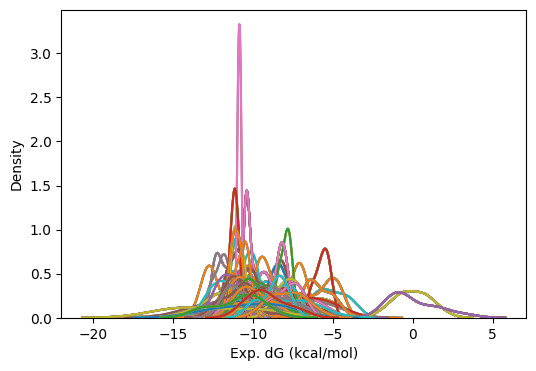

In [64]:
plot_dg_dist(results)

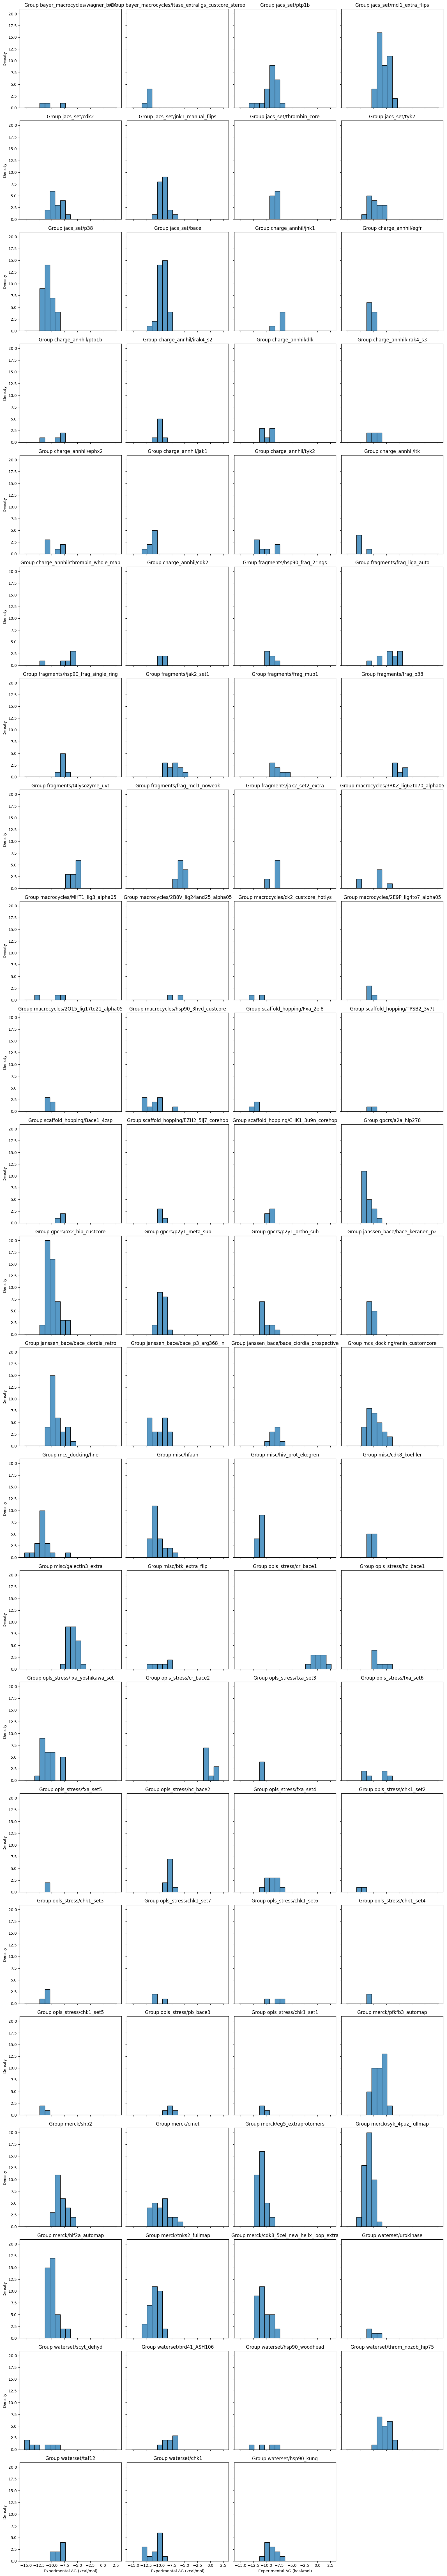

In [58]:
plot_dg_hist_grid(results)